# NB02: 성남시 건물 추출 및 층수 정보 통합

**목적**: 경기도 전체 건물 shapefile에서 성남시 건물만 추출하고, 건물 층수 데이터 통합

**입력**: 
- `00_data/(연속수치지형도)건물_경기/N3A_B0010000_41_A.shp` + `_B.shp` (EPSG:5179, ~2.8GB)
- `processed/seongnam_boundary.gpkg` (NB01 출력)
- 건물 층수 데이터 (V-World WFS 또는 건축물대장 → `00_data/추가/building_floors/`)

**출력**: `processed/seongnam_buildings.gpkg`

> **NOTE**: 건물 shapefile에는 층수/높이 필드가 없음. 별도 데이터 필요.  
> 데이터 미확보 시 우선 footprint만 추출하고, 층수는 이후 병합.

In [1]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

BASE = Path(r"C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam")
RAW = BASE / "00_data"
OUT = BASE / "processed"

# 성남시 경계 로드 (EPSG:5179, 거리계산용)
seongnam = gpd.read_file(OUT / "seongnam_boundary.gpkg", layer="dong_5179")
bounds = seongnam.total_bounds  # (minx, miny, maxx, maxy)
print(f"성남시 Bounds (EPSG:5179): {bounds}")

# 약간의 버퍼 추가 (500m)
BBOX = (bounds[0] - 500, bounds[1] - 500, bounds[2] + 500, bounds[3] + 500)
print(f"건물 로드용 bbox (500m 버퍼): {BBOX}")

성남시 Bounds (EPSG:5179): [ 958182.9834 1926109.5141  973093.1936 1941780.0392]
건물 로드용 bbox (500m 버퍼): (np.float64(957682.9834000003), np.float64(1925609.5141000003), np.float64(973593.1935999999), np.float64(1942280.0392000005))


## 1. 건물 shapefile 로드 (bbox 필터로 성남 영역만)

경기도 전체 건물 shapefile이 ~2.8GB이므로, `bbox` 파라미터로 성남 영역만 로드하여 메모리 절약

In [2]:
%%time
# 건물 A + B 파일 로드 (bbox 필터 적용)
bldg_dir = RAW / "(연속수치지형도)건물_경기"

buildings = []
for suffix in ["A", "B"]:
    fpath = bldg_dir / f"N3A_B0010000_41_{suffix}.shp"
    print(f"로드 중: {fpath.name}...", end=" ")
    gdf = gpd.read_file(fpath, bbox=BBOX)
    print(f"{len(gdf):,}건")
    buildings.append(gdf)

gdf_bldg = pd.concat(buildings, ignore_index=True)
print(f"\nbbox 내 전체 건물: {len(gdf_bldg):,}건")
print(f"컬럼: {gdf_bldg.columns.tolist()}")

로드 중: N3A_B0010000_41_A.shp... 

113,523건
로드 중: N3A_B0010000_41_B.shp... 

1,023건

bbox 내 전체 건물: 114,546건
컬럼: ['UFID', 'BJCD', 'NAME', 'DIVI', 'KIND', 'SERV', 'ANNO', 'NMLY', 'RDNM', 'BONU', 'BUNU', 'POST', 'SCLS', 'FMTA', 'GIDN', 'geometry']
CPU times: total: 19.6 s
Wall time: 20.2 s


## 2. 성남시 경계로 정밀 클리핑 (bbox는 사각형이므로 경계 밖 건물 제거)

In [3]:
# 성남시 전체 경계로 spatial join (contains/intersects)
city_5179 = seongnam.dissolve()
gdf_bldg_seongnam = gpd.sjoin(gdf_bldg, city_5179[["geometry"]], predicate="intersects", how="inner")
gdf_bldg_seongnam = gdf_bldg_seongnam.drop(columns="index_right")

print(f"성남시 내 건물: {len(gdf_bldg_seongnam):,}건 (bbox: {len(gdf_bldg):,} → 정밀 클리핑)")
print(f"\n건물 속성 샘플:")
print(gdf_bldg_seongnam.drop(columns="geometry").head())

성남시 내 건물: 78,305건 (bbox: 114,546 → 정밀 클리핑)

건물 속성 샘플:
                  UFID        BJCD  NAME  DIVI    KIND    SERV  ANNO  NMLY  \
368  B0010000000QR17ST  4113511700  None  None  BDK005  BDS999  None     1   
369  B0010000000QR17TU  4113511800  None  None  BDK005  BDS999  None     1   
372  B0010000000QR17WX  4113111300  None  None  BDK005  BDS999  None     1   
373  B0010000000QR17XY  4113111300  None  None  BDK005  BDS999  None     1   
374  B0010000000QR17YZ  4113111300  None  None  BDK005  BDS999  None     1   

     RDNM  BONU  BUNU  POST      SCLS       FMTA  GIDN  
368  None     0     0  None  B0014116  R23124821  None  
369  None     0     0  None  B0014116  R23124822  None  
372  None     0     0  None  B0014116  R23124825  None  
373  None     0     0  None  B0014116  R23124826  None  
374  None     0     0  None  B0014116  R23124827  None  


## 3. 건물 층수 데이터 병합

> **TODO**: `00_data/추가/building_floors/` 에 V-World WFS 또는 건축물대장 데이터가 있으면 여기서 병합  
> 미확보 시 건물 면적으로 임시 추정 (대형 건물 = 고층 확률 높음)

In [4]:
import os

floor_dir = BASE / "00_data" / "추가" / "building_floors"
floor_files = list(floor_dir.glob("*")) if floor_dir.exists() else []

if floor_files:
    # 층수 데이터 로드 및 병합 (파일 형식에 따라 조정 필요)
    print(f"건물 층수 데이터 발견: {[f.name for f in floor_files]}")
    # TODO: 형식에 맞게 조인 로직 구현
    # df_floors = pd.read_csv(floor_files[0])
    # gdf_bldg_seongnam = gdf_bldg_seongnam.merge(df_floors, on="PNU_KEY", how="left")
else:
    print("⚠ 건물 층수 데이터 미확보 — 건물 면적 기반 임시 분류 적용")
    print("  → V-World WFS 또는 건축물대장 API에서 층수 데이터 다운로드 후 이 셀 재실행")
    
    # 건물 면적 계산 (EPSG:5179는 미터 단위이므로 면적 계산 가능)
    gdf_bldg_seongnam["area_m2"] = gdf_bldg_seongnam.geometry.area
    
    # 건물 유형 임시 분류 (면적 기반)
    # 대형 건물(>1000m²)이면서 KIND 속성이 아파트 등이면 고층 추정
    gdf_bldg_seongnam["est_floors"] = None  # 층수 미정 상태로 표시
    gdf_bldg_seongnam["is_large"] = gdf_bldg_seongnam["area_m2"] > 1000
    
    print(f"\n건물 면적 통계:")
    print(f"  전체: {len(gdf_bldg_seongnam):,}건")
    print(f"  대형 (>1000m²): {gdf_bldg_seongnam['is_large'].sum():,}건")
    print(f"  평균 면적: {gdf_bldg_seongnam['area_m2'].mean():.1f}m²")

⚠ 건물 층수 데이터 미확보 — 건물 면적 기반 임시 분류 적용
  → V-World WFS 또는 건축물대장 API에서 층수 데이터 다운로드 후 이 셀 재실행

건물 면적 통계:
  전체: 78,305건
  대형 (>1000m²): 1,339건
  평균 면적: 145.5m²


## 4. 저장 (EPSG:5179 + EPSG:4326 dual)

저장 완료: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam\processed\seongnam_buildings.gpkg
  - buildings_5179: 78,305건 (EPSG:5179)
  - buildings_4326: 78,305건 (EPSG:4326)


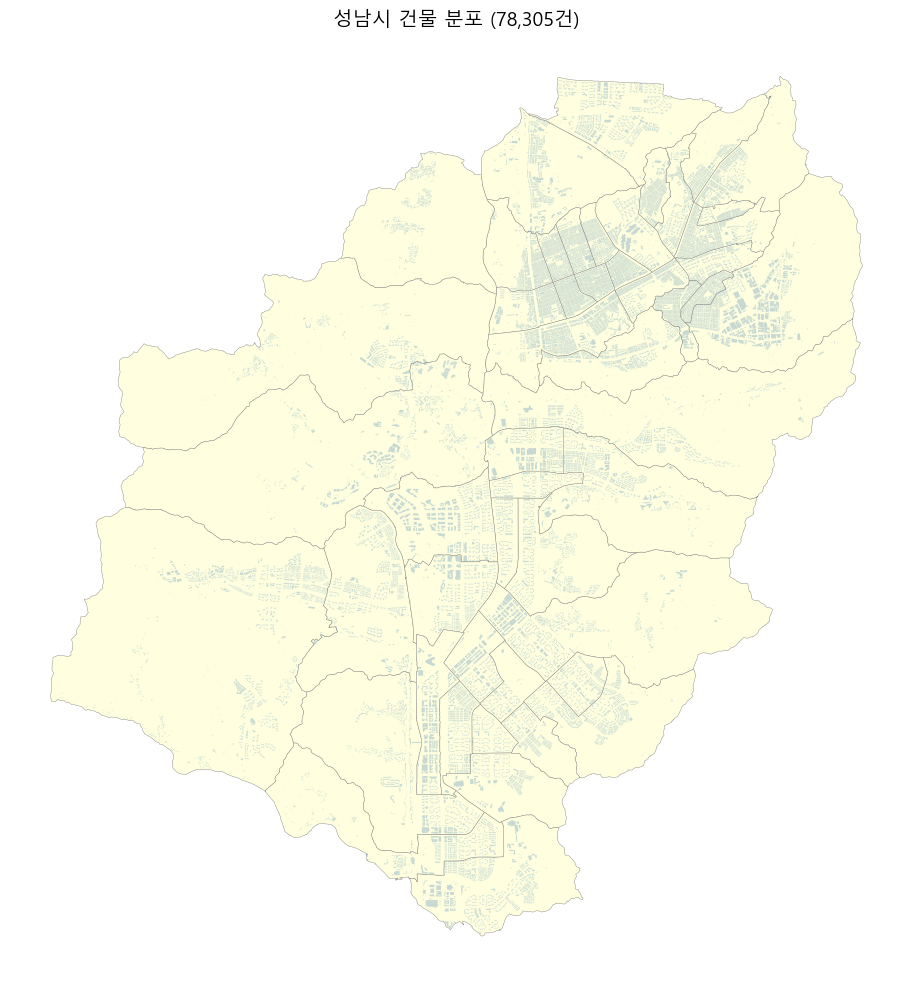

In [5]:
# EPSG:5179 (거리 계산용) 저장
gdf_bldg_seongnam.to_file(OUT / "seongnam_buildings.gpkg", layer="buildings_5179", driver="GPKG")

# EPSG:4326 (웹 지도/Tableau용) 변환 및 저장
gdf_bldg_4326 = gdf_bldg_seongnam.to_crs(epsg=4326)
gdf_bldg_4326.to_file(OUT / "seongnam_buildings.gpkg", layer="buildings_4326", driver="GPKG")

print(f"저장 완료: {OUT / 'seongnam_buildings.gpkg'}")
print(f"  - buildings_5179: {len(gdf_bldg_seongnam):,}건 (EPSG:5179)")
print(f"  - buildings_4326: {len(gdf_bldg_4326):,}건 (EPSG:4326)")

# 건물 밀도 맵 (간단 시각화)
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
seongnam_4326 = seongnam.to_crs(epsg=4326)
seongnam_4326.plot(ax=ax, edgecolor="gray", facecolor="lightyellow", linewidth=0.3)
gdf_bldg_4326.plot(ax=ax, color="steelblue", markersize=0.1, alpha=0.3)
ax.set_title(f"성남시 건물 분포 ({len(gdf_bldg_seongnam):,}건)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()